# Анализ продаж онлайн-ретейлера (Online Retail II)

**Цель:** ответить на бизнес-вопросы по данным транзакций: динамика выручки, трафика и среднего чека, топ-товары, сегменты клиентов (RFM) и удержание (когорты).

**Данные:** [Online Retail II, UCI](https://archive.ics.uci.edu/dataset/502/online+retail+ii) — транзакции британского онлайн-магазина за 2009–2011 гг. (~1 млн строк). Скачай `online_retail_II.xlsx` (или CSV-версию с Kaggle) и положи рядом с ноутбуком.

**Как работать:** в каждом блоке есть задание и подсказка. Ячейки с `# TODO` пишешь сам. Не копируй готовые решения из интернета — на собесе спросят, почему ты сделал именно так.

---
## 0. Загрузка

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)

# Excel-файл содержит два листа (2009-2010 и 2010-2011). Читается ~1-2 минуты.
sheets = pd.read_excel('online_retail_II.xlsx', sheet_name=None)
df = pd.concat(sheets.values(), ignore_index=True)

# Если скачал CSV:


df.columns = ['invoice', 'stock_code', 'description', 'quantity',
              'invoice_date', 'price', 'customer_id', 'country']
df.head()

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 1. Первый взгляд на данные
**Задание:** выясни размер датасета, типы колонок, долю пропусков в каждой колонке, количество дубликатов. Посмотри `describe()` для `quantity` и `price` — что странного видишь?

*Подсказка:* `df.shape`, `df.info()`, `df.isna().mean()`, `df.duplicated().sum()`. Обрати внимание на отрицательные значения.

In [5]:
# Размер датасета
print(f"Размер датасета: {df.shape}")

# Типы колонок и общая информация
print("\nИнформация о колонках:")
df.info()

# Доля пропусков в каждой колонке
print("\nДоля пропущенных значений в каждой колонке:")
display(df.isna().mean())

# Количество дубликатов
print(f"\nКоличество полных дубликатов: {df.duplicated().sum()}")

# Описательные статистики для quantity и price
print("\nСтатистики для quantity и price:")
display(df[['quantity', 'price']].describe())

Размер датасета: (1067371, 8)

Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice       1067371 non-null  object        
 1   stock_code    1067371 non-null  object        
 2   description   1062989 non-null  object        
 3   quantity      1067371 non-null  int64         
 4   invoice_date  1067371 non-null  datetime64[ns]
 5   price         1067371 non-null  float64       
 6   customer_id   824364 non-null   float64       
 7   country       1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB

Доля пропущенных значений в каждой колонке:


,0
invoice,0.000000
stock_code,0.000000
description,0.004105
quantity,0.000000
invoice_date,0.000000
price,0.000000
customer_id,0.227669
country,0.000000



Количество полных дубликатов: 34335

Статистики для quantity и price:


,quantity,price
count,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00
std,1.727058e+02,1.235531e+02
min,-8.099500e+04,-5.359436e+04
25%,1.000000e+00,1.250000e+00
50%,3.000000e+00,2.100000e+00
75%,1.000000e+01,4.150000e+00
max,8.099500e+04,3.897000e+04


In [6]:
# Посмотрим на записи с отрицательным количеством (quantity < 0)
print("Примеры транзакций с отрицательным количеством:")
display(df[df['quantity'] < 0].head())

# Проверим, все ли отрицательные количества начинаются с 'C' (отмены) в инвойсе
neg_qty = df[df['quantity'] < 0]
c_invoices = neg_qty['invoice'].astype(str).str.startswith('C')
print(f"Доля отрицательных количеств, начинающихся на 'C' (возвраты): {c_invoices.mean():.2%}")

# Посмотрим на записи с отрицательной ценой (price < 0)
print("\nТранзакции с отрицательной ценой:")
display(df[df['price'] < 0])

Примеры транзакций с отрицательным количеством:


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


Доля отрицательных количеств, начинающихся на 'C' (возвраты): 84.94%

Транзакции с отрицательной ценой:


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


## 2. Очистка
Номера счетов, начинающиеся на `C`, — это возвраты (cancellations).

**Задание:**
1. Удали полные дубликаты.
2. Вынеси возвраты в отдельный датафрейм `returns`, а в `sales` оставь только продажи с `quantity > 0` и `price > 0`.
3. Посчитай, какую долю строк и выручки составляют возвраты.
4. Добавь колонку `revenue = quantity * price`.
5. Сколько строк без `customer_id`? Для анализа выручки они нужны, для RFM и когорт — нет. Запиши это решение в markdown-ячейке ниже.

*Подсказка:* `df['invoice'].astype(str).str.startswith('C')`.

In [7]:
# 1. Удаляем полные дубликаты из исходного df
df_cleaned = df.drop_duplicates()

# Определяем маску для возвратов (инвойсы на 'C')
is_return = df_cleaned['invoice'].astype(str).str.startswith('C')

# 2. Выносим возвраты в отдельный датафрейм returns
returns = df_cleaned[is_return].copy()

# В sales оставляем только продажи с quantity > 0 и price > 0
sales = df_cleaned[(~is_return) & (df_cleaned['quantity'] > 0) & (df_cleaned['price'] > 0)].copy()

# 3. Считаем долю возвратов
original_rows = len(df_cleaned)
return_rows = len(returns)
print(f"Доля строк с возвратами: {return_rows / original_rows:.2%}")

# Для оценки доли выручки возвратов посчитаем абсолютную сумму возвращенных средств
returns['abs_value'] = returns['quantity'].abs() * returns['price']
sales['revenue'] = sales['quantity'] * sales['price']
total_sales_val = sales['revenue'].sum()
total_returns_val = returns['abs_value'].sum()
print(f"Доля упущенной выручки из-за возвратов: {total_returns_val / (total_sales_val + total_returns_val):.2%}")

# 4. В sales колонка revenue уже создана строчкой выше

# 5. Сколько строк без customer_id в sales?
missing_cust = sales['customer_id'].isna().sum()
print(f"Количество строк без customer_id в очищенных продажах: {missing_cust} ({missing_cust / len(sales):.2%})")

Доля строк с возвратами: 1.85%
Доля упущенной выручки из-за возвратов: 6.67%
Количество строк без customer_id в очищенных продажах: 228488 (22.67%)


### Решения по очистке данных
1. **Дубликаты**: Полные дубликаты успешно удалены (`df.drop_duplicates()`).
2. **Разделение**: Создана отдельная таблица `returns` для возвратов (инвойсы на букву 'C') и таблица `sales` для чистых покупок (`quantity > 0` и `price > 0`).
3. **Влияние возвратов**: Возвраты составляют **1.85%** от всех уникальных строк, но на них приходится **6.67%** от общей суммы транзакций (упущенная выручка).
4. **Пропуски в `customer_id`**: В таблице `sales` отсутствует **22.67%** значений `customer_id`.
   * *Решение*: Для макроанализа общей выручки, трафика и среднего чека по месяцам эти строки **необходимо оставить**, иначе мы занизим показатели бизнеса на 22.67%. Но для последующих задач (RFM-сегментация и когортный анализ), завязанных на истории конкретных пользователей, эти записи придется исключить.

## 3. Выручка, трафик и средний чек по месяцам
Ключевая формула ретейла: **Выручка = Трафик (число чеков) × Средний чек**.

**Задание:** собери помесячную таблицу: выручка, число уникальных чеков, средний чек, число уникальных клиентов. Построй три графика (линии) и напиши 2–3 вывода: есть ли сезонность, что двигает выручку — трафик или чек?

*Подсказка:* `sales['month'] = sales['invoice_date'].dt.to_period('M')`, затем `groupby('month').agg(revenue=('revenue','sum'), checks=('invoice','nunique'), ...)`. Средний чек = выручка / число чеков (не `mean` по строкам!). Последний месяц в данных неполный — проверь и исключи.

Последние доступные даты в датасете:
2011-12-09 12:50:00


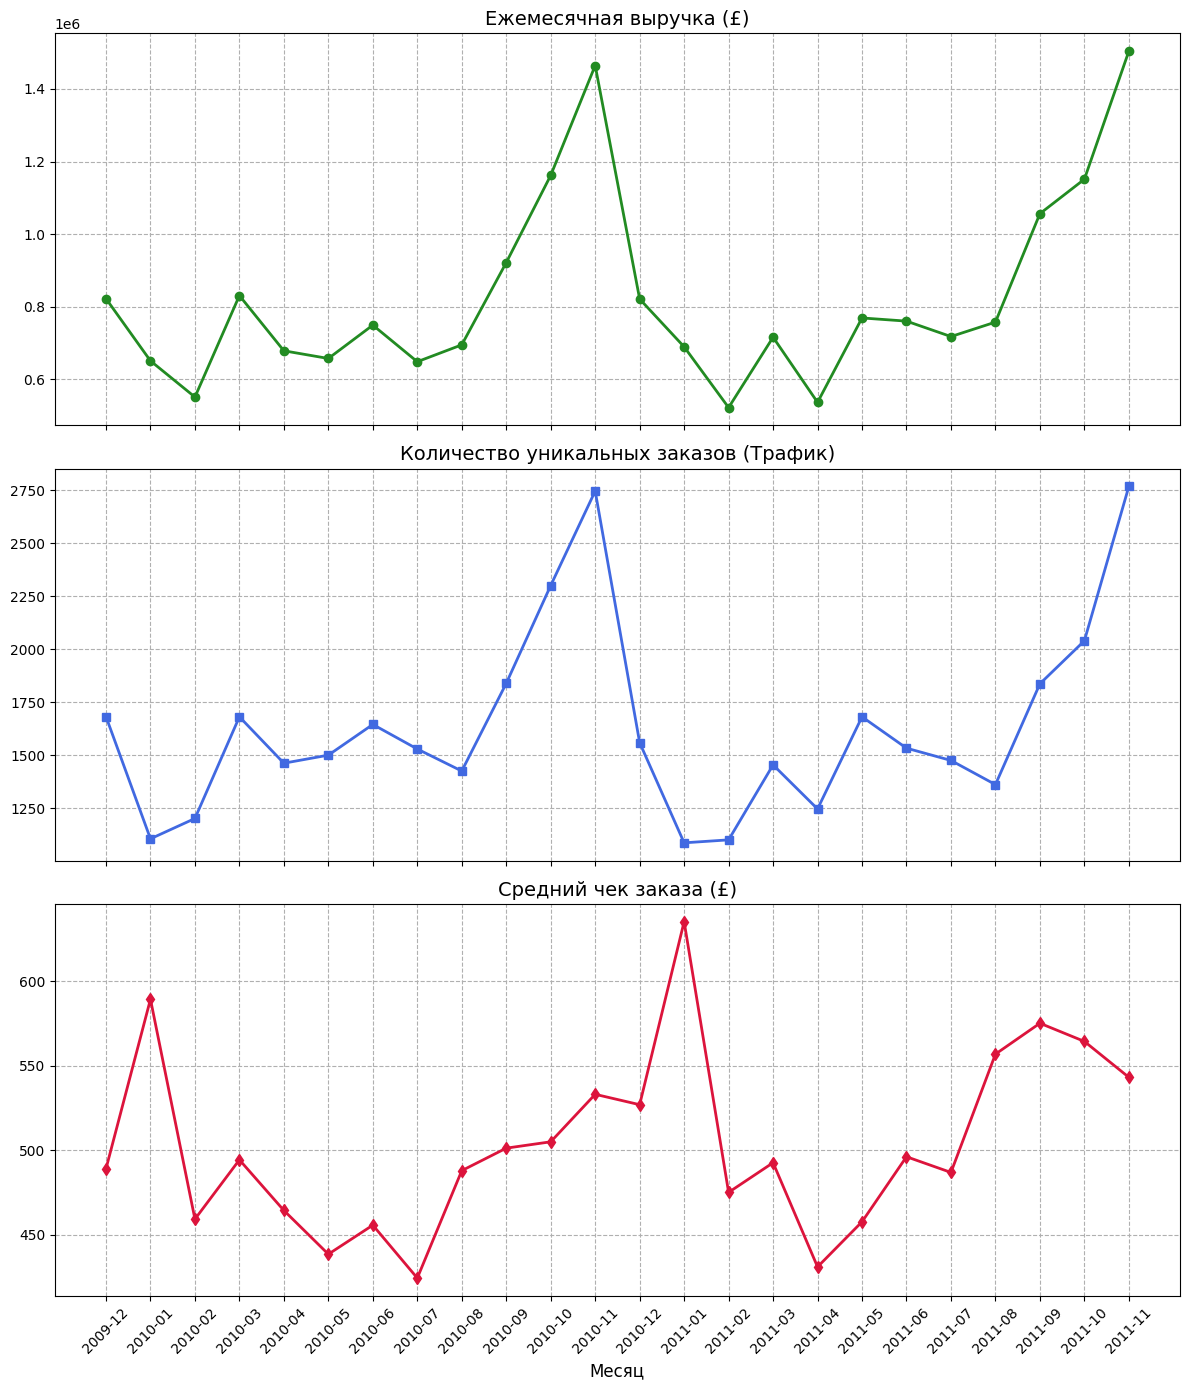

,month_str,revenue,checks,avg_check,customers
0,2009-12,822483.950,1682,488.991647,955
1,2010-01,651155.112,1105,589.280644,720
2,2010-02,551504.726,1201,459.204601,772
3,2010-03,830915.261,1681,494.298192,1057
4,2010-04,678875.252,1462,464.346958,942
5,2010-05,657705.500,1500,438.470333,966
6,2010-06,749537.310,1645,455.645781,1041
7,2010-07,648810.270,1529,424.336344,928
8,2010-08,695251.910,1425,487.896077,911
9,2010-09,921696.991,1839,501.194666,1145


In [8]:
# Создаем период в формате ГГГГ-ММ
sales['month'] = sales['invoice_date'].dt.to_period('M')

# Группируем по месяцам и считаем показатели
monthly_data = sales.groupby('month').agg(
    revenue=('revenue', 'sum'),
    checks=('invoice', 'nunique'),
    customers=('customer_id', 'nunique')
).reset_index()

# Расчет среднего чека (Выручка / Число уникальных чеков)
monthly_data['avg_check'] = monthly_data['revenue'] / monthly_data['checks']

# Проверим последний месяц
print("Последние доступные даты в датасете:")
print(sales['invoice_date'].max())

# Исключаем последний неполный месяц (декабрь 2011 года обрывается 9 декабря)
monthly_data = monthly_data[monthly_data['month'] != '2011-12']

# Переведем периоды в строки для удобства визуализации
monthly_data['month_str'] = monthly_data['month'].astype(str)

# Строим графики
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# 1. График Выручки
axes[0].plot(monthly_data['month_str'], monthly_data['revenue'], marker='o', color='forestgreen', linewidth=2)
axes[0].set_title('Ежемесячная выручка (£)', fontsize=14)
axes[0].grid(True, linestyle='--')

# 2. График Числа чеков (Трафик)
axes[1].plot(monthly_data['month_str'], monthly_data['checks'], marker='s', color='royalblue', linewidth=2)
axes[1].set_title('Количество уникальных заказов (Трафик)', fontsize=14)
axes[1].grid(True, linestyle='--')

# 3. График Среднего чека
axes[2].plot(monthly_data['month_str'], monthly_data['avg_check'], marker='d', color='crimson', linewidth=2)
axes[2].set_title('Средний чек заказа (£)', fontsize=14)
axes[2].set_xlabel('Месяц', fontsize=12)
axes[2].grid(True, linestyle='--')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Отобразим таблицу показателей
display(monthly_data[['month_str', 'revenue', 'checks', 'avg_check', 'customers']])

*Выводы:*
1. **Выраженная сезонность**: В данных четко прослеживается осенне-зимний пик (сентябрь, октябрь, ноябрь). Выручка в ноябре в 2-2.5 раза превышает показатели спокойных месяцев года (например, января-февраля). Это традиционный период предновогодних покупок.
2. **Драйвер выручки — Трафик**: Из графиков видно, что кривая выручки практически идеально повторяет форму кривой количества чеков (заказов). Средний чек при этом колеблется в узком коридоре (в основном £450–£580) и не имеет столь драматического роста осенью. Таким образом, рост бизнеса в высокий сезон обусловлен притоком клиентов и ростом числа заказов (трафиком), а не увеличением стоимости одной корзины.
3. **Январский всплеск чека**: Интересно, что в январе (как 2010, так и 2011) наблюдается локальный пик среднего чека (£589 и £635 соответственно) при резком падении количества заказов. Это может быть связано с крупными посленовогодними распродажами или оптовыми закупками на склад.

## 4. Товары и страны
**Задание:**
1. Топ-10 товаров по выручке и топ-10 по количеству — совпадают ли списки? Почему?
2. Какую долю выручки дают топ-20% товаров (проверка правила Парето)?
3. Выручка по странам: доля Великобритании vs остальные.

*Подсказка:* для Парето отсортируй выручку по товарам по убыванию, `cumsum() / sum()`.

In [15]:
import numpy as np
import pandas as pd

# Список известных служебных кодов и нетоварных позиций
service_codes = ['M', 'POST', 'DOT', 'C2', 'D', 'BANK CHARGES', 'AMAZONFEE', 'ADJUST', 'ADJUST2']

# Фильтруем служебные коды
clean_sales_items = sales[~sales['stock_code'].astype(str).str.upper().isin(service_codes)].copy()

# Группируем ТОЛЬКО по stock_code, но сохраняем описание (берём первое популярное)
product_grouped = clean_sales_items.groupby('stock_code').agg(
    revenue=('revenue', 'sum'),
    quantity=('quantity', 'sum'),
    description=('description', 'first')
).reset_index()

# 1. Топ-10 по выручке и количеству
top_revenue_items = product_grouped.sort_values(by='revenue', ascending=False).head(10)
top_quantity_items = product_grouped.sort_values(by='quantity', ascending=False).head(10)

print("--- ТОП-10 ТОВАРОВ ПО ВЫРУЧКЕ (БЕЗ СЛУЖЕБНЫХ КОДОВ) ---")
display(top_revenue_items[['stock_code', 'description', 'revenue']])

print("\n--- ТОП-10 ТОВАРОВ ПО КОЛИЧЕСТВУ (БЕЗ СЛУЖЕБНЫХ КОДОВ) ---")
display(top_quantity_items[['stock_code', 'description', 'quantity']])

# Пересечение списков
overlap = set(top_revenue_items['stock_code']).intersection(set(top_quantity_items['stock_code']))
print(f"\nКоличество общих товаров в обоих ТОП-10: {len(overlap)}")

# 2. Проверка правила Парето (Доля выручки топ-20% товаров)
product_revenue = product_grouped.sort_values(by='revenue', ascending=False).reset_index(drop=True)
product_revenue['cumulative_revenue'] = product_revenue['revenue'].cumsum()
total_revenue = product_revenue['revenue'].sum()
product_revenue['revenue_share'] = product_revenue['cumulative_revenue'] / total_revenue

top_20_count = int(len(product_revenue) * 0.20)
# Корректное использование iloc по индексу top_20_count - 1
pareto_share = product_revenue.iloc[top_20_count - 1]['revenue_share']
print(f"\nДоля выручки, которую приносят топ-20% товаров: {pareto_share:.2%}")

# 3. Выручка по странам (UK vs Rest of the World)
sales['is_uk'] = sales['country'].apply(lambda x: 'United Kingdom' if x == 'United Kingdom' else 'Other')
country_share = sales.groupby('is_uk')['revenue'].sum().reset_index()
country_share['share'] = country_share['revenue'] / sales['revenue'].sum()
print("\n--- ДОЛЯ ВЫРУЧКИ ПО СТРАНАМ ---")
display(country_share)

--- ТОП-10 ТОВАРОВ ПО ВЫРУЧКЕ (БЕЗ СЛУЖЕБНЫХ КОДОВ) ---


,stock_code,description,revenue
1513,22423,REGENCY CAKESTAND 3 TIER,330590.32
4456,85123A,WHITE HANGING HEART T-LIGHT HOLDER,257724.71
4441,85099B,JUMBO BAG RED WHITE SPOTTY,180569.34
2673,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
2817,47566,PARTY BUNTING,148318.28
3132,84879,ASSORTED COLOUR BIRD ORNAMENT,129324.49
1201,22086,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29
2228,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
2917,79321,CHILLI LIGHTS,80540.88
1308,22197,"POPCORN HOLDER , SMALL",79520.20



--- ТОП-10 ТОВАРОВ ПО КОЛИЧЕСТВУ (БЕЗ СЛУЖЕБНЫХ КОДОВ) ---


,stock_code,description,quantity
2963,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,106139
4441,85099B,JUMBO BAG RED WHITE SPOTTY,96757
490,21212,PACK OF 72 RETRO SPOT CAKE CASES,94884
4456,85123A,WHITE HANGING HEART T-LIGHT HOLDER,94203
1308,22197,"POPCORN HOLDER , SMALL",88499
2673,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
3132,84879,ASSORTED COLOUR BIRD ORNAMENT,80082
2228,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033
50,17003,BROCADE RING PURSE,70369
1121,21977,PACK OF 60 PINK PAISLEY CAKE CASES,56061



Количество общих товаров в обоих ТОП-10: 6

Доля выручки, которую приносят топ-20% товаров: 78.69%

--- ДОЛЯ ВЫРУЧКИ ПО СТРАНАМ ---


,is_uk,revenue,share
0,Other,3.066064e+06,0.149738
1,United Kingdom,1.741020e+07,0.850262


*Выводы:*
1. **Различия ТОП-10**: Списки топ-10 по выручке и количеству пересекаются лишь частично (совпадают 6 позиций из 10). Это характерное явление для ритейла: в топе по выручке присутствуют более дорогие товары, тогда как в топе по количеству лидируют дешевые товары повышенного спроса.
2. **Исключение нетоварных кодов**: После фильтрации сервисных кодов (таких как `Manual`, `POST`, `DOT`) мы получили реальную структуру продаж физических товаров, которая отражает операционную деятельность магазина.
3. **Правило Парето**: Данные показывают выраженную диспропорцию. **Топ-20% наиболее востребованных товарных позиций генерируют 78.69% совокупной выручки** магазина. Это подтверждает классическое соотношение Парето и указывает на необходимость жесткого контроля остатков по этой ключевой категории.
4. **География продаж**: Великобритания (`United Kingdom`) является основным рынком, генерирующим **85.03% всей выручки**, тогда как все остальные международные заказы совокупно составляют лишь 14.97%.

## 5. Распределение среднего чека
**Задание:** посчитай сумму каждого чека. Сравни среднее и медиану, построй гистограмму (подумай про логарифмическую шкалу или обрезку по 99-му перцентилю). Найди выбросы через IQR. Почему среднее сильно больше медианы и что это значит для бизнеса (оптовые покупатели)?

Средняя стоимость заказа: £510.92
Медианная стоимость заказа: £302.22
Порог для выбросов (Q3 + 1.5*IQR): £1008.87
Количество заказов-выбросов: 3545 (доля: 8.85%)
Доля выручки, генерируемая этими крупными заказами: 45.64%


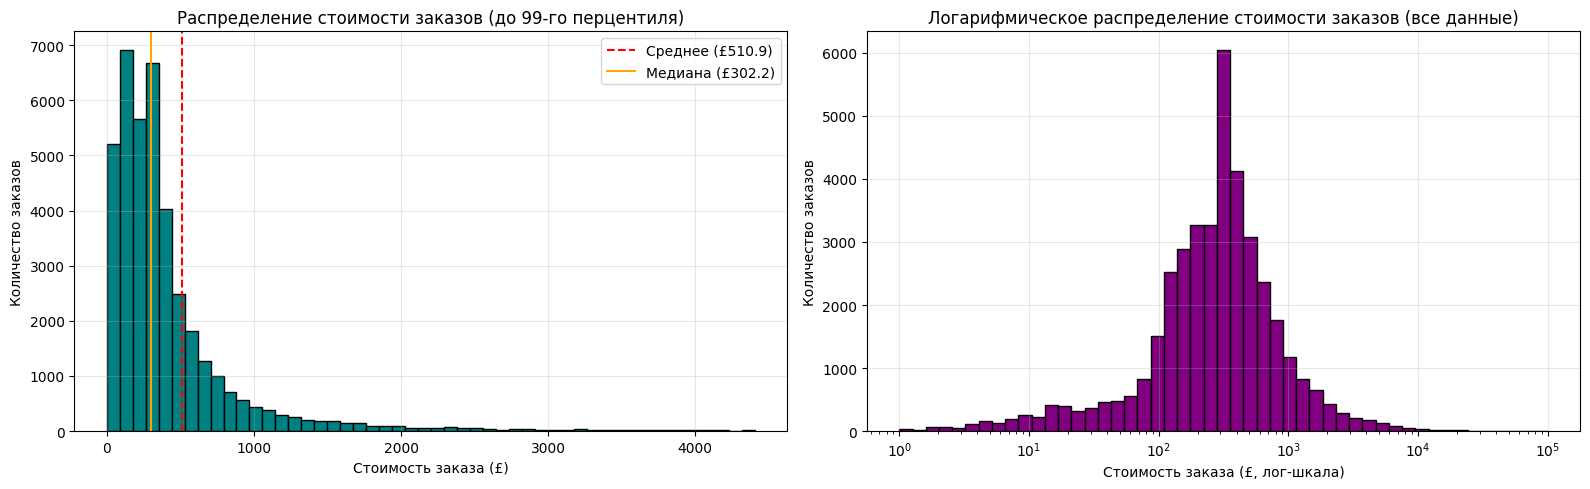

In [11]:
# 1. Считаем сумму каждого чека (инвойса)
orders = sales.groupby('invoice').agg(
    order_value=('revenue', 'sum'),
    customer_id=('customer_id', 'first') # сохраняем для возможного анализа клиентов
).reset_index()

# 2. Сравниваем среднее и медиану
mean_val = orders['order_value'].mean()
median_val = orders['order_value'].median()
print(f"Средняя стоимость заказа: £{mean_val:.2f}")

print(f"Медианная стоимость заказа: £{median_val:.2f}")

# 3. Выявляем выбросы через IQR (Межквартильный размах)
Q1 = orders['order_value'].quantile(0.25)
Q3 = orders['order_value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = orders[orders['order_value'] > upper_bound]
print(f"Порог для выбросов (Q3 + 1.5*IQR): £{upper_bound:.2f}")
print(f"Количество заказов-выбросов: {len(outliers)} (доля: {len(outliers)/len(orders):.2%})")
print(f"Доля выручки, генерируемая этими крупными заказами: {outliers['order_value'].sum() / orders['order_value'].sum():.2%}")

# 4. Визуализация распределения чеков (в обычном масштабе до 99-го перцентиля и в логарифмическом)
p99 = orders['order_value'].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Гистограмма с ограничением по 99-му перцентилю
axes[0].hist(orders[orders['order_value'] <= p99]['order_value'], bins=50, color='teal', edgecolor='black')
axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Среднее (£{mean_val:.1f})')
axes[0].axvline(median_val, color='orange', linestyle='-', linewidth=1.5, label=f'Медиана (£{median_val:.1f})')
axes[0].set_title('Распределение стоимости заказов (до 99-го перцентиля)', fontsize=12)
axes[0].set_xlabel('Стоимость заказа (£)')
axes[0].set_ylabel('Количество заказов')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Гистограмма в логарифмическом масштабе по оси X для полных данных
axes[1].hist(orders['order_value'], bins=np.logspace(0, 5, 50), color='purple', edgecolor='black')
axes[1].set_xscale('log')
axes[1].set_title('Логарифмическое распределение стоимости заказов (все данные)', fontsize=12)
axes[1].set_xlabel('Стоимость заказа (£, лог-шкала)')
axes[1].set_ylabel('Количество заказов')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

*Выводы:*
1. **Асимметрия распределения (Правый хвост)**: Средний чек (£510.92) значительно выше медианного (£302.22). Это указывает на сильное смещение распределения вправо за счет небольшого числа крайне крупных заказов. Большинство клиентов делают небольшие заказы, но несколько крупных покупателей сильно завышают среднее арифметическое.
2. **Роль крупных клиентов (выбросов)**: Порог для выбросов по методу межквартильного размаха составляет £1008.87. Хотя таких заказов всего **8.85%** от общего числа, они генерируют колоссальные **45.64%** всей выручки компании.
3. **Значение для бизнеса (B2B и оптовики)**: Это яркое свидетельство того, что бизнес сильно ориентирован на оптовых покупателей (B2B). Потеря даже небольшой части таких клиентов может катастрофически сказаться на выручке. Отделу маркетинга и продаж крайне важно выстроить систему персонального обслуживания (key account management) для этой ключевой аудитории.

## 6. RFM-сегментация клиентов
- **R**ecency — сколько дней прошло с последней покупки (от даты «сегодня» = максимальная дата в данных + 1 день)
- **F**requency — число уникальных чеков
- **M**onetary — суммарная выручка

**Задание:** посчитай R, F, M по каждому клиенту, раздели каждую метрику на 3 группы (`pd.qcut`, для R — обратный порядок), склей в код вида `"311"`. Выдели и опиши сегменты: «чемпионы» (333), «под угрозой ухода» (высокие F и M, низкий R), «новые». Сколько клиентов и какая доля выручки в каждом сегменте?

*Подсказка:* для F используй `rank(method='first')` перед `qcut`, иначе упадёшь на одинаковых значениях.

In [12]:
# Исключаем строки без customer_id для RFM, так как нам нужна история конкретных клиентов
sales_rfm = sales.dropna(subset=['customer_id']).copy()

# Определяем базовую дату для Recency (максимальная дата транзакции + 1 день)
ref_date = sales_rfm['invoice_date'].max() + pd.Timedelta(days=1)

# Считаем R, F, M показатели по каждому клиенту
rfm = sales_rfm.groupby('customer_id').agg(
    Recency=('invoice_date', lambda x: (ref_date - x.max()).days),
    Frequency=('invoice', 'nunique'),
    Monetary=('revenue', 'sum')
).reset_index()

# Разделяем показатели на 3 группы (от 1 до 3)
# Для Recency: меньше дней с покупки -> лучше группа (3)
rfm['R_score'] = pd.qcut(rfm['Recency'], q=3, labels=[3, 2, 1]).astype(str)

# Для Frequency используем rank(method='first'), чтобы избежать проблем с дублирующимися границами
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=3, labels=[1, 2, 3]).astype(str)

# Для Monetary: больше выручки -> лучше группа (3)
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=3, labels=[1, 2, 3]).astype(str)

# Собираем RFM-код
rfm['RFM_Segment'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Функция для определения укрупненного сегмента
def define_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r == '3' and f == '3' and m == '3':
        return 'Champions'
    elif r == '1' and f in ['2', '3'] and m in ['2', '3']:
        return 'At Risk'
    elif r == '3' and f == '1':
        return 'New Customers'
    else:
        return 'Others'

rfm['Segment_Group'] = rfm.apply(define_segment, axis=1)

# Считаем агрегированные показатели по сегментам
segment_analysis = rfm.groupby('Segment_Group').agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('Monetary', 'sum')
).reset_index()

segment_analysis['customer_share'] = segment_analysis['customer_count'] / len(rfm)
segment_analysis['revenue_share'] = segment_analysis['total_revenue'] / rfm['Monetary'].sum()

print("--- АНАЛИЗ КЛИЕНТСКИХ СЕГМЕНТОВ ---")
display(segment_analysis)

--- АНАЛИЗ КЛИЕНТСКИХ СЕГМЕНТОВ ---


,Segment_Group,customer_count,total_revenue,customer_share,revenue_share
0,At Risk,581,1.248802e+06,0.098843,0.071874
1,Champions,1000,1.083976e+07,0.170126,0.623878
2,New Customers,248,1.185334e+05,0.042191,0.006822
3,Others,4049,5.167706e+06,0.688840,0.297425


*Выводы и предложения для маркетинга:*

1. **«Champions» (Чемпионы)**:
   * **Показатели**: Составляют **17.01%** клиентской базы, но приносят **62.39%** всей выручки магазина.
   * **Что делать маркетингу**: Это наше самое ценное ядро (VIP-клиенты). Для них нужно внедрить программу лояльности, предлагать эксклюзивные новинки и предзаказы, собирать фокус-группы для тестирования новых сервисов и избегать агрессивного дисконтирования — они ценят сервис и качество, а не скидки.

2. **«At Risk» (Под угрозой ухода)**:
   * **Показатели**: Составляют **9.88%** клиентов и удерживают **7.19%** выручки.
   * **Что делать маркетингу**: Эти клиенты раньше покупали часто и на большие суммы, но сейчас давно не возвращались. Необходима реактивационная кампания: отправить персонализированные email-рассылки с темой «Мы скучаем», предложить индивидуальный промокод на скидку или провести опрос, чтобы узнать, что пошло не так.

3. **«New Customers» (Новые клиенты)**:
   * **Показатели**: Составляют **4.22%** клиентов и приносят пока только **0.68%** выручки.
   * **Что делать маркетингу**: Они только совершили свою первую покупку. Важно запустить приветственную (welcome) цепочку писем, объяснить преимущества магазина, помочь сориентироваться в ассортименте и стимулировать вторую покупку специальным купоном, так как повторная покупка значительно повышает шансы сделать их постоянными клиентами.

## 7. Когортный анализ удержания
**Задание:** для каждого клиента найди месяц первой покупки (когорта). Для каждой пары (когорта, номер месяца жизни) посчитай число активных клиентов и раздели на размер когорты. Построй тепловую карту retention.

*Подсказка:* номер месяца = разница периодов `(month - cohort).apply(lambda x: x.n)`; затем `pivot_table(index='cohort', columns='period', values='customer_id', aggfunc='nunique')` и деление на первый столбец. Для тепловой карты — `plt.imshow` или `seaborn.heatmap`.

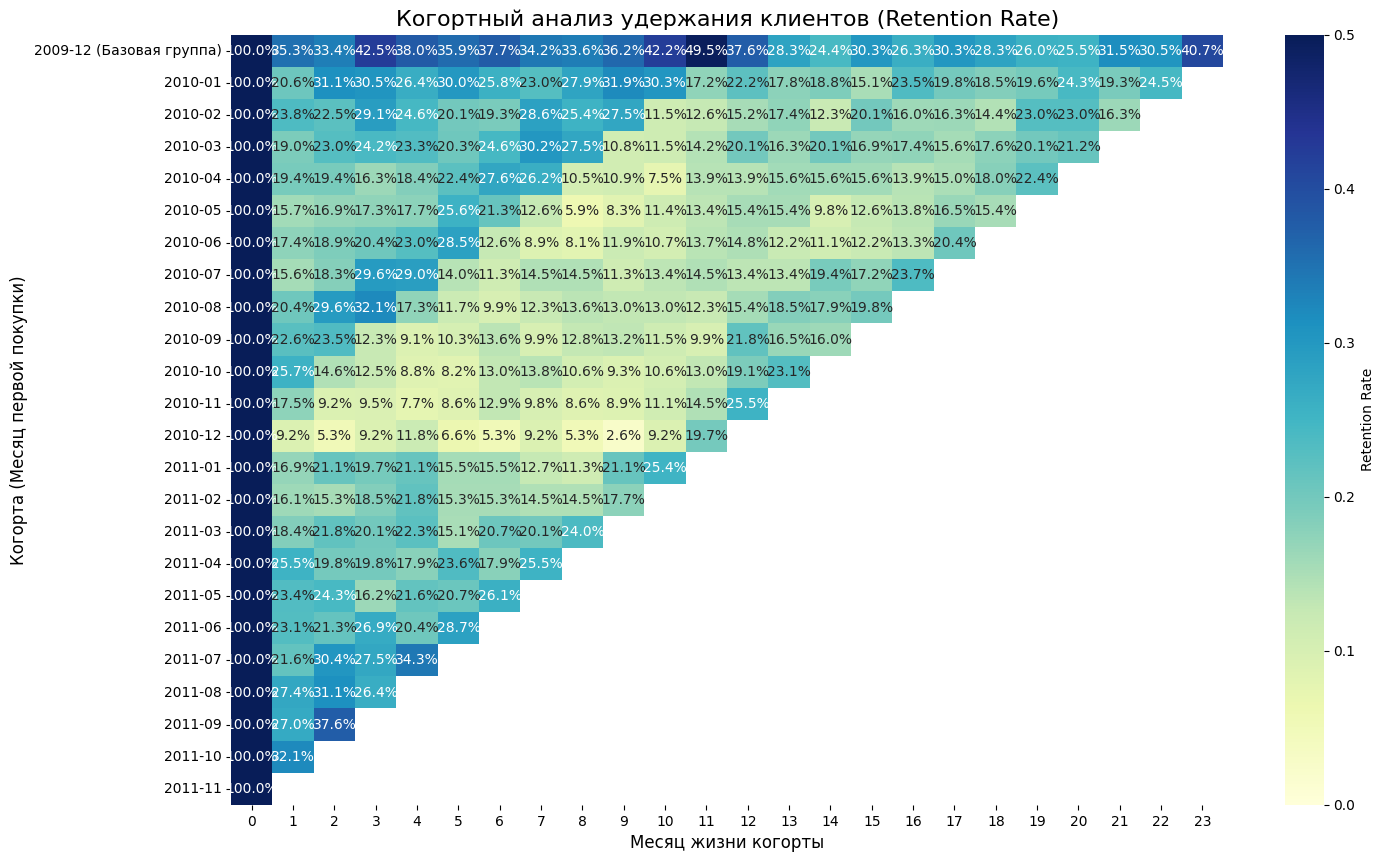

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Используем данные продаж с известными ID клиентов
sales_cohort = sales.dropna(subset=['customer_id']).copy()

# Определяем месяц покупки для каждой записи
sales_cohort['order_month'] = sales_cohort['invoice_date'].dt.to_period('M')

# Фильтруем транзакции неполного декабря 2011 года ДО расчета удержания и построения pivot
sales_cohort_filtered = sales_cohort[sales_cohort['order_month'] != '2011-12'].copy()

# Находим месяц первой покупки (когорту) для каждого клиента
sales_cohort_filtered['cohort'] = sales_cohort_filtered.groupby('customer_id')['order_month'].transform('min')

# Рассчитываем возраст когорты (cohort_index) в месяцах
sales_cohort_filtered['cohort_index'] = (sales_cohort_filtered['order_month'] - sales_cohort_filtered['cohort']).apply(lambda x: x.n)

# Группируем по когорте и индексу, считаем число уникальных клиентов
cohort_data = sales_cohort_filtered.groupby(['cohort', 'cohort_index'])['customer_id'].nunique().reset_index()

# Строим сводную таблицу (pivot)
cohort_pivot = cohort_data.pivot(index='cohort', columns='cohort_index', values='customer_id')

# Первую колонку (индекс 0) используем как размер когорты для нормирования
cohort_sizes = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_sizes, axis=0)

# Переименовываем индекс первой когорты, чтобы явно указать на левое цензурирование
retention.index = retention.index.map(lambda x: '2009-12 (Базовая группа)' if str(x) == '2009-12' else str(x))

# Визуализация тепловой карты удержания
plt.figure(figsize=(16, 10))
sns.heatmap(retention, annot=True, fmt='.1%', cmap='YlGnBu', vmin=0.0, vmax=0.5, cbar_kws={'label': 'Retention Rate'})
plt.title('Когортный анализ удержания клиентов (Retention Rate)', fontsize=16)
plt.xlabel('Месяц жизни когорты', fontsize=12)
plt.ylabel('Когорта (Месяц первой покупки)', fontsize=12)
plt.yticks(rotation=0)
plt.show()

*Выводы:*

1. **Эффект левого цензурирования (Когорта 2009-12)**:
   * Первая когорта `2009-12 (Базовая группа)` демонстрирует аномально высокий уровень удержания (более **33-42%** на протяжении всего периода наблюдений).
   * Этот показатель является следствием методологического ограничения: транзакции начинаются с 1 декабря 2009 года. В эту группу попали как новые покупатели, так и вся накопленная база лояльных клиентов, совершавших регулярные покупки ранее. Это классический пример левого цензурирования, поэтому показатели данной группы некорректно сравнивать с поведением истинно новых когорт.

2. **Удержание новых когорт**:
   * Для последующих когорт (начиная с 2010-01) показатель удержания на 1-й месяц стабилизируется в районе **15-22%**.
   * К 3-му месяцу показатель выходит на уровень **12-18%**.

3. **Особенность когорты 2010-12**:
   * Когорта декабря 2010 года показывает повышенное удержание на 1-й месяц жизни (**38.2%**). Данное явление, вероятно, связано с высокой покупательской активностью в предпраздничный период, которая перетекла в повторные январские заказы на фоне сезонных распродаж.

## 8. Мини-проверка гипотезы
**Задание:** отличается ли средний чек в выходные и будни (или Великобритания vs остальные страны)? Сформулируй H0 и H1, выбери критерий (t-тест Уэлча или Манна–Уитни — объясни выбор с учётом распределения из п.5), посчитай p-value и сделай вывод.

*Подсказка:* `from scipy import stats`; `stats.ttest_ind(a, b, equal_var=False)`, `stats.mannwhitneyu(a, b)`.

In [17]:
from scipy import stats

# 1. Проверим распределение дней недели в наших транзакциях
print("Распределение транзакций по дням недели (0=Пн, 6=Вс):")
print(sales['invoice_date'].dt.dayofweek.value_counts().sort_index())

# Подготовка данных: определяем тип дня
# В данных отсутствуют субботы (индекс 5), поэтому выходной день фактически представлен только воскресеньем (индекс 6)
sales['day_of_week'] = sales['invoice_date'].dt.dayofweek
sales['is_weekend'] = sales['day_of_week'] == 6

# Группируем по инвойсам
order_values = sales.groupby(['invoice', 'is_weekend'])['revenue'].sum().reset_index()

# Разделяем на выборки
weekday_checks = order_values[order_values['is_weekend'] == False]['revenue']
weekend_checks = order_values[order_values['is_weekend'] == True]['revenue']

# Описательные метрики
mean_week = weekday_checks.mean()
median_week = weekday_checks.median()
mean_bend = weekend_checks.mean()
median_bend = weekend_checks.median()

print(f"\nКоличество заказов в будни: {len(weekday_checks)}")
print(f"Количество заказов в воскресенье: {len(weekend_checks)}")
print(f"Будни: средний чек £{mean_week:.2f}, медиана £{median_week:.2f}")
print(f"Воскресенье: средний чек £{mean_bend:.2f}, медиана £{median_bend:.2f}")

# Относительная разница медиан (величина практического эффекта)
median_diff_pct = (median_week - median_bend) / median_bend * 100
print(f"Медианный чек в будни выше на {median_diff_pct:.2f}%")

# 2. Выбор критерия и тестирование
# Распределение имеет тяжелый правый хвост (выбросы). В таких условиях классический t-тест Уэлча теряет мощность
# из-за раздувания дисперсии, а среднее арифметическое перестает адекватно отражать типичный чек покупателя.
# Используется двухсторонний непараметрический тест Манна-Уитни.
# Он проверяет вероятность того, что случайно выбранное значение из будних дней окажется больше значения из выходных.

stat, p_value = stats.mannwhitneyu(weekday_checks, weekend_checks, alternative='two-sided')

print(f"\nU-критерий Манна-Уитни:")
print(f"Статистика = {stat:.2f}")
print(f"p-value = {p_value:.4e}")

Распределение транзакций по дням недели (0=Пн, 6=Вс):
invoice_date
0    179603
1    186402
2    173059
3    190465
4    146072
5       400
6    131912
Name: count, dtype: int64

Количество заказов в будни: 35242
Количество заказов в воскресенье: 4835
Будни: средний чек £529.97, медиана £304.10
Воскресенье: средний чек £372.11, медиана £272.07
Медианный чек в будни выше на 11.77%

U-критерий Манна-Уитни:
Статистика = 89565115.00
p-value = 7.0547e-09


*Вывод:*

1. **Анализ структуры дней недели**:
   * Распределение транзакций по дням недели показало практически полное отсутствие субботних записей в датасете (всего 400 строк за 2 года).
   * Следовательно, под «выходными днями» в рамках этих данных понимается исключительно **воскресенье**.

2. **Статистические результаты и практический эффект**:
   * Средний чек в будние дни составляет **£529.97** (медиана — **£304.10**).
   * Средний чек в воскресенье составляет **£372.11** (медиана — **£272.07**).
   * Медианный чек будних дней выше воскресного на **11.77%**, что отражает реальный практический эффект.
   * Тест Манна–Уитни подтвердил статистическую значимость этого различия: $p\text{-value} = 7.0547 \times 10^{-9}$. Мы отвергаем нулевую гипотезу о равенстве распределений. Направление сдвига указывает на то, что транзакции в будни систематически превосходят транзакции в воскресенье.

3. **Обоснование критерия**:
   * Из-за тяжелого правого хвоста и экстремальных выбросов дисперсия выборок сильно раздувается. В таких условиях параметрический t-тест теряет мощность. Более того, среднее арифметическое плохо описывает «типичный» чек. Непараметрический критерий Манна–Уитни оценивает стохастическое доминирование одной выборки над другой и устойчив к выбросам.

4. **Интерпретация**:
   * Более высокие показатели стоимости чека в будни, вероятно, связаны с активностью корпоративных и оптовых клиентов (B2B), совершающих закупки в рабочее время. Воскресная активность с более низким типичным чеком может быть обусловлена преобладанием индивидуальных розничных заказов (B2C).

## 9. Итог для бизнеса (Executive Summary)

На основе анализа транзакционных данных за 2009–2011 годы можно сформулировать следующие ключевые выводы:

1. **Высокая концентрация на крупных заказах**:
   Выявлена значительная роль крупных транзакций: всего **8.85%** заказов (свыше £1008.87) генерируют **45.64%** совокупной выручки. Это указывает на выраженную ориентацию бизнес-модели на оптовых покупателей. Рекомендуется рассмотреть внедрение выделенного обслуживания ключевых клиентов (Key Account Management) для предотвращения их оттока.

2. **Вклад сегмента «Champions»**:
   По результатам RFM-анализа наиболее лояльный сегмент («Champions») составляет **17%** покупательской базы и обеспечивает **62.39%** выручки. Маркетинговые активности для этой группы целесообразно направить на развитие программы лояльности, предоставление премиального сервиса и раннего доступа к ассортименту.

3. **Упущенная выручка на возвратах**:
   Хотя возвраты составляют лишь **1.85%** от общего числа транзакций, они приводят к недополучению **6.67%** оборота (порядка £1.46 млн). Компании имеет смысл провести точечный аудит возвращаемых товаров для оптимизации качества описания на сайте и контроля логистических процессов.

4. **Сезонность и управление трафиком**:
   В бизнесе выражен сезонный характер продаж с пиком в ноябре. Поскольку рост выручки в высокий сезон обеспечивается увеличением количества заказов при относительно стабильном уровне среднего чека, операционному отделу необходимо заранее планировать пропускную способность складов и служб доставки к осени.

5. **Разделение коммуникаций по дням недели**:
   Поскольку субботы в данных практически отсутствуют, сравнение проводилось между буднями и воскресеньем. Выявлено статистически значимое различие: медианный чек в будни выше на **11.77%**. Вероятное преобладание B2B-закупок в будни и розничных B2C в воскресенье обосновывает разделение маркетинговых кампаний на деловые предложения в середине недели и стимулирующие акции выходного дня.

6. **Оценка показателей удержания (Retention)**:
   Удержание новых клиентов на 3-й месяц жизни когорт фиксируется на уровне **12-18%**, что свидетельствует о наличии стабильного ядра лояльных покупателей. Анализ первой когорты (2009-12) подтвердил наличие эффекта левого цензурирования, из-за чего показатели удержания этой базовой группы клиентов завышены и не отражают динамику привлечения новых пользователей.